# BoltzGen MVP 运行复盘

**运行编号：** `boltzgen_nanobody_mps_smoke_001`  
**任务：** 在本地 Apple Silicon MPS 上，以 GLP-1(7–36) 为正靶，运行 `nanobody-anything` 最小端到端链路。  
**复盘原则：** 本 Notebook 只读取既有结果，不重跑模型；所有结论均来自保存的输入指纹、日志、CSV、NPZ 与 CIF 文件。

## TL;DR

下面的摘要由实际输出动态生成。这里严格区分三件事：

1. **工程链路是否跑通**；
2. **是否生成并排序候选**；
3. **候选是否通过预设质量门槛**。

In [1]:
# 导入复盘所需的轻量库；这里不会导入 BoltzGen、PyTorch 或任何模型权重。
from __future__ import annotations

import hashlib
import json
import logging
import re
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


# macOS 的 PingFang 在 Matplotlib 中会把 bold 自动映射到可用的 600 字重；
# 这只是字体匹配信息，不影响渲染。关闭该专用 logger，保持已执行 Notebook 输出干净。
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


# Notebook 通常从 ``mvp_run_001/notebooks`` 执行；下面同时兼容从其他目录重跑。
def locate_run_root(start: Path) -> Path:
    """向上寻找同时含 inputs 与 outputs 的 mvp_run_001 根目录。"""

    resolved = start.resolve()
    for candidate in (resolved, *resolved.parents):
        if (candidate / "inputs").is_dir() and (candidate / "outputs/02_mps_run").is_dir():
            return candidate
    raise FileNotFoundError("无法定位 mvp_run_001：需要同时存在 inputs/ 与 outputs/02_mps_run/。")


RUN_ROOT = locate_run_root(Path.cwd())
ANALYSIS_DIR = RUN_ROOT / "analysis"
PIPELINE_DIR = RUN_ROOT / "outputs/02_mps_run/pipeline"
FIGURE_DIR = RUN_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 载入不可变的运行状态与输入清单；这两份 JSON 是本次真实执行的审计入口。
with (RUN_ROOT / "outputs/02_mps_run/mvp_run_status.json").open(encoding="utf-8") as handle:
    run_status = json.load(handle)
with (RUN_ROOT / "outputs/02_mps_run/input_manifest.json").open(encoding="utf-8") as handle:
    input_manifest = json.load(handle)


def compatible_csv(candidates: list[Path], required_columns: set[str]) -> tuple[pd.DataFrame, Path]:
    """优先读取 analysis 汇总；统一列名后若仍不兼容，再回退到原始 CSV。"""

    # analysis/candidate_metrics.csv 使用带单位、面向阅读者的列名；BoltzGen 原始表
    # 使用内部短列名。这里仅重命名同义列，不重算或覆盖任何数值，使下游代码可以
    # 对两种来源使用同一套审计逻辑，同时在展示中保留实际选中的来源路径。
    analysis_to_canonical = {
        "candidate_id": "id",
        "final_rank_within_this_run": "final_rank",
        "designed_sequence_concatenated": "designed_sequence",
        "designed_residue_count": "num_design",
        "pass_all_default_filters": "pass_filters",
        "filter_rmsd_angstrom": "filter_rmsd",
        "filter_rmsd_design_angstrom": "filter_rmsd_design",
        "binding_site_residues_within_8A": "bindsite_under_8rmsd",
        "delta_sasa_refolded_angstrom2": "delta_sasa_refolded",
        "interface_hbond_count": "plip_hbonds_refolded",
        "interface_saltbridge_atom_pair_count": "plip_saltbridge_refolded",
        "liability_score_proxy": "liability_score",
        "liability_violation_count": "liability_num_violations",
        "min_design_to_target_pae_angstrom": "min_design_to_target_pae",
    }

    errors = []
    for path in candidates:
        if not path.exists():
            continue
        try:
            frame = pd.read_csv(path).rename(columns=analysis_to_canonical)
        except Exception as exc:  # 记录但不中止，让旧版/临时汇总不会破坏复盘。
            errors.append(f"{path.name}: {exc}")
            continue
        if required_columns.issubset(frame.columns):
            return frame, path
        errors.append(f"{path.name}: 缺少 {sorted(required_columns - set(frame.columns))}")
    raise RuntimeError("没有可用的候选指标文件。检查结果：" + "; ".join(errors))


# 下游图表和审计结论实际依赖这些列。将完整列集合用于兼容性检查，可避免
# analysis/ 中出现“只有摘要列”的临时文件时，Notebook 误选它后才在后续单元报错。
required_candidate_columns = {
    "id",
    "final_rank",
    "designed_sequence",
    "pass_filters",
    "num_design",
    "design_to_target_iptm",
    "min_design_to_target_pae",
    "design_ptm",
    "filter_rmsd",
    "filter_rmsd_design",
    "bindsite_under_8rmsd",
    "delta_sasa_refolded",
    "plip_hbonds_refolded",
    "plip_saltbridge_refolded",
    "liability_score",
    "liability_num_violations",
    "pass_has_x_filter",
    "pass_filter_rmsd_filter",
    "pass_filter_rmsd_design_filter",
    "pass_bindsite_under_8rmsd_filter",
    "pass_CYS_fraction_filter",
    "pass_ALA_fraction_filter",
    "pass_GLY_fraction_filter",
    "pass_GLU_fraction_filter",
    "pass_LEU_fraction_filter",
    "pass_VAL_fraction_filter",
}

# 允许后续流程在 analysis/ 写入完整汇总，同时确保当前 Notebook 可从原始结果独立重建。
candidate_metrics, candidate_source = compatible_csv(
    [
        ANALYSIS_DIR / "candidate_metrics.csv",
        ANALYSIS_DIR / "candidate_summary.csv",
        PIPELINE_DIR / "final_ranked_designs/all_designs_metrics.csv",
    ],
    required_candidate_columns,
)

# 加载最终预算表；它表示排序器实际写出的候选，不代表该候选通过了硬过滤。
final_metrics = pd.read_csv(PIPELINE_DIR / "final_ranked_designs/final_designs_metrics_1.csv")

# 设置中文图表字体与统一色板；找不到首选字体时由 Matplotlib 自动回退。
plt.rcParams.update(
    {
        "font.sans-serif": ["PingFang SC", "Arial Unicode MS", "Heiti SC", "DejaVu Sans"],
        "axes.unicode_minus": False,
        "figure.dpi": 120,
        "axes.titleweight": "bold",
        "axes.edgecolor": "#64748b",
        "axes.labelcolor": "#334155",
        "xtick.color": "#475569",
        "ytick.color": "#475569",
    }
)

print(f"运行根目录：{RUN_ROOT}")
print(f"候选指标来源：{candidate_source.relative_to(RUN_ROOT)}")

运行根目录：$PROJECT_ROOT/data/boltzgen_data/mvp_run_001
候选指标来源：analysis/candidate_metrics.csv


In [2]:
# 从执行状态和候选表计算摘要，避免在结论中手工抄写可能过期的数字。
requested = int(input_manifest["requested_designs"])
generated = len(list((PIPELINE_DIR / "intermediate_designs").glob("*.cif")))
inverse_folded = len(list((PIPELINE_DIR / "intermediate_designs_inverse_folded").glob("*.cif")))
refolded = len(list((PIPELINE_DIR / "intermediate_designs_inverse_folded/refold_cif").glob("*.cif")))
analyzed = len(candidate_metrics)
hard_passed = int(candidate_metrics["pass_filters"].fillna(False).astype(bool).sum())
selected = len(final_metrics)

# 确保摘要中的数量关系合理；若产物被移动或截断，Notebook 会明确报错而非静默展示。
assert requested == 2, f"本次审计预期请求 2 个候选，实际清单为 {requested}。"
assert generated == inverse_folded == refolded == analyzed == 2, (
    "候选在设计、逆折叠、复折叠或分析阶段的数量不一致："
    f"{generated=}, {inverse_folded=}, {refolded=}, {analyzed=}"
)
assert selected == 1, f"最终预算应写出 1 个候选，实际为 {selected}。"

display(
    Markdown(
        f"""
> **工程结论：链路完整跑通。** 请求 {requested} 个候选，设计、逆折叠、复折叠和分析均完成 {analyzed}/{requested}，所有 5 个模型/分析步骤返回成功。  
> **质量结论：本轮没有合格候选。** 预设硬过滤通过数为 **{hard_passed}/{analyzed}**。  
> **输出解释：** 最终目录仍写出 {selected} 个 rank-1 候选，这是“预算内的相对最优项”，**不是**“通过质量门槛的命中”。  
> **本轮价值：** 证明实验性 MPS 路径、输入解析、生成、逆折叠、复折叠、指标计算和结果落盘能够闭环；结果不足以支持结合、活性或 7–36/9–36 选择性结论。
"""
    )
)


> **工程结论：链路完整跑通。** 请求 2 个候选，设计、逆折叠、复折叠和分析均完成 2/2，所有 5 个模型/分析步骤返回成功。  
> **质量结论：本轮没有合格候选。** 预设硬过滤通过数为 **0/2**。  
> **输出解释：** 最终目录仍写出 1 个 rank-1 候选，这是“预算内的相对最优项”，**不是**“通过质量门槛的命中”。  
> **本轮价值：** 证明实验性 MPS 路径、输入解析、生成、逆折叠、复折叠、指标计算和结果落盘能够闭环；结果不足以支持结合、活性或 7–36/9–36 选择性结论。


## 输入指纹

输入由四类文件组成：顶层设计规格、GLP-1 目标结构、VHH scaffold 配方和原始 7XL0 scaffold 结构。运行清单还固定了四个推理资产。下表重新计算 SHA-256，并与运行前保存的指纹比较。

In [3]:
def sha256_file(path: Path, block_size: int = 1024 * 1024) -> str:
    """分块计算文件 SHA-256，避免将大 checkpoint 一次性读入内存。"""

    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()


# 校验项目输入；路径使用运行根目录下的相对位置，因此复制整个目录后仍可复核。
input_rows = []
for item in input_manifest["input_files"]:
    path = RUN_ROOT / item["path"]
    actual_hash = sha256_file(path)
    input_rows.append(
        {
            "输入文件": item["path"],
            "字节数": path.stat().st_size,
            "保存SHA-256": item["sha256"],
            "当前SHA-256": actual_hash,
            "一致": actual_hash == item["sha256"],
        }
    )

input_fingerprint_df = pd.DataFrame(input_rows)
assert input_fingerprint_df["一致"].all(), "至少一个输入文件已变化，不能把当前文件视为原运行输入。"
display(input_fingerprint_df.style.format({"字节数": "{:,}"}))

# checkpoint 较大，但完整重算哈希仍是最可靠的输入确认；结果应全部为 True。
asset_rows = []
for item in input_manifest["runtime_assets"]:
    path = Path(item["path"])
    actual_hash = sha256_file(path)
    asset_rows.append(
        {
            "运行资产": item["asset"],
            "文件": path.name,
            "大小(GiB)": path.stat().st_size / 1024**3,
            "SHA-256一致": actual_hash == item["sha256"],
        }
    )

asset_fingerprint_df = pd.DataFrame(asset_rows)
assert asset_fingerprint_df["SHA-256一致"].all(), "至少一个运行资产与执行时指纹不一致。"
display(asset_fingerprint_df.style.format({"大小(GiB)": "{:.3f}"}))

,输入文件,字节数,保存SHA-256,当前SHA-256,一致
0,inputs/glp1_7_36_nanobody_mvp.yaml,"1,390",f1d8a6af70bb0db49e02dbc1d18294df1aa32da29c8253a0581e148d37388113,f1d8a6af70bb0db49e02dbc1d18294df1aa32da29c8253a0581e148d37388113,True
1,inputs/target/6X18_GLP1_7-36_geometry.cif,"17,614",11b82b2633793e6799f1d56c19a88fd52828bec5d26d9366801753dfa72d2d53,11b82b2633793e6799f1d56c19a88fd52828bec5d26d9366801753dfa72d2d53,True
2,inputs/scaffold/7xl0_mvp_scaffold.yaml,"1,917",65a0badf61dd239aaf4fe6831f2f5c5efb833eaa86d1a99fade6833fef03fc00,65a0badf61dd239aaf4fe6831f2f5c5efb833eaa86d1a99fade6833fef03fc00,True
3,inputs/scaffold/7XL0_official_example.cif,"451,294",0042fd3761f1aee883db62f72f86b8a5fca75198d9e2f265be197b7d44320c34,0042fd3761f1aee883db62f72f86b8a5fca75198d9e2f265be197b7d44320c34,True


,运行资产,文件,大小(GiB),SHA-256一致
0,design_diverse,boltzgen1_diverse.ckpt,1.798,True
1,inverse_fold,boltzgen1_ifold.ckpt,0.012,True
2,folding,boltz2_conf_final.ckpt,1.944,True
3,molecule_dictionary,mols.zip,0.365,True


### 输入语义

- **正靶：** `6X18_GLP1_7-36_geometry.cif`，仅保留 30 aa 的 GLP-1 链 E。
- **热点提示：** 顶层 YAML 将链 E 的位置 1、2（His7、Ala8）标为 `binding`，目的是引导候选靠近 DPP-4 截短时被删除的 N 端二肽。
- **设计对象：** 7XL0 VHH 链 A；固定框架，隐藏并重设计三段 CDR，对三个锚点允许可变长度插入。
- **结构注意：** 输入检查日志中的“设计残基数”会随可变长度插入的抽样变化，因此 check/configure 出现 39 与 38 并不代表文件被改写。实际两个候选的设计长度分别为 42 和 44 aa。

## 运行方法

本轮不是训练，也没有更新模型权重。它是在 BoltzGen v0.3.2 基线上，使用未合并 MPS PR 的固定提交，执行一次低预算、低采样步数的推理冒烟测试。

In [4]:
# 展示复现实验所需的版本、平台、协议与快速设置；值全部来自输入清单。
method_rows = [
    ("运行类别", input_manifest["execution_class"]),
    ("官方基线", input_manifest["official_release_baseline"]),
    ("MPS 补丁提交", input_manifest["experimental_mps_pr_commit"]),
    ("平台", input_manifest["platform"]),
    ("Python", input_manifest["python"].split("|")[0].strip()),
    ("协议", "nanobody-anything"),
    ("候选数 / 最终预算", f"{input_manifest['requested_designs']} / {input_manifest['final_budget']}"),
    ("设计采样步数", input_manifest["fast_smoke_settings"]["design_sampling_steps"]),
    ("逆折叠采样步数", input_manifest["fast_smoke_settings"]["inverse_fold_sampling_steps"]),
    ("折叠采样步数", input_manifest["fast_smoke_settings"]["folding_sampling_steps"]),
    ("每候选折叠样本", input_manifest["fast_smoke_settings"]["folding_samples_per_candidate"]),
    ("recycling", input_manifest["fast_smoke_settings"]["recycling_steps"]),
    ("精度", input_manifest["fast_smoke_settings"]["precision"]),
]
display(pd.DataFrame(method_rows, columns=["参数", "本轮取值"]))

# 命令来自执行状态，不重新执行；保留它是为了让后续人员能审计参数，而非复制即跑。
configure_stage = next(stage for stage in run_status["stages"] if stage["stage"] == "02_configure")
display(Markdown("### 已执行的配置命令\n```bash\n" + configure_stage["command_display"] + "\n```"))

# 用输入—处理—输出表明确每一步的数据边界。
io_rows = [
    ("check", "顶层 YAML + 目标 CIF + scaffold YAML/CIF + mols.zip", "着色输入检查 CIF；不调用模型"),
    ("design", "结构条件、CDR 可设计掩码、binding 位点、diverse checkpoint", "2 个骨架 CIF + 2 个 token 元数据 NPZ"),
    ("inverse_folding", "设计骨架 + CDR 设计掩码 + inverse-fold checkpoint", "2 条含氨基酸序列的 VHH 候选 CIF/NPZ"),
    ("folding", "候选序列/复合物 + Boltz-2 folding checkpoint", "2 个复折叠复合物 CIF + 置信度/坐标 NPZ"),
    ("analysis", "原生成结构、复折叠结构、序列", "239 列聚合指标、每靶指标、逐候选 metrics NPZ"),
    ("filtering", "聚合指标 + 过滤阈值 + budget=1", "全候选排名表、1 个预算输出、PDF 总览"),
]
display(pd.DataFrame(io_rows, columns=["步骤", "输入", "输出"]))

,参数,本轮取值
0,运行类别,experimental_mps_smoke_test
1,官方基线,BoltzGen v0.3.2
2,MPS 补丁提交,592317f0f5582730b28c144267a15631c07fcb94
3,平台,macOS-26.2-arm64-arm-64bit
4,Python,3.12.13
5,协议,nanobody-anything
6,候选数 / 最终预算,2 / 1
7,设计采样步数,50
8,逆折叠采样步数,30
9,折叠采样步数,50


### 已执行的配置命令
```bash
$PROJECT_ROOT/data/boltzgen_data/mvp_run_001/env/bin/boltzgen configure $PROJECT_ROOT/data/boltzgen_data/mvp_run_001/inputs/glp1_7_36_nanobody_mvp.yaml --output $PROJECT_ROOT/data/boltzgen_data/mvp_run_001/outputs/02_mps_run/pipeline --protocol nanobody-anything --num_designs 2 --budget 1 --diffusion_batch_size 1 --devices 1 --num_workers 1 --use_kernels false --moldir $PROJECT_ROOT/data/boltzgen_data/mvp_assets_v0.3.2/runtime_cache/mols.zip --design_checkpoints $PROJECT_ROOT/data/boltzgen_data/mvp_assets_v0.3.2/runtime_cache/boltzgen1_diverse.ckpt --inverse_fold_checkpoint $PROJECT_ROOT/data/boltzgen_data/mvp_assets_v0.3.2/runtime_cache/boltzgen1_ifold.ckpt --folding_checkpoint $PROJECT_ROOT/data/boltzgen_data/mvp_assets_v0.3.2/runtime_cache/boltz2_conf_final.ckpt --config design sampling_steps=50 recycling_steps=1 trainer.precision=32 --config inverse_folding sampling_steps=30 recycling_steps=1 trainer.precision=32 --config folding sampling_steps=50 recycling_steps=1 diffusion_samples=1 trainer.precision=32 --config analysis liability_modality=antibody num_processes=1 --config filtering modality=antibody filter_bindingsite=true
```

,步骤,输入,输出
0,check,顶层 YAML + 目标 CIF + scaffold YAML/CIF + mols.zip,着色输入检查 CIF；不调用模型
1,design,结构条件、CDR 可设计掩码、binding 位点、diverse checkpoint,2 个骨架 CIF + 2 个 token 元数据 NPZ
2,inverse_folding,设计骨架 + CDR 设计掩码 + inverse-fold checkpoint,2 条含氨基酸序列的 VHH 候选 CIF/NPZ
3,folding,候选序列/复合物 + Boltz-2 folding checkpoint,2 个复折叠复合物 CIF + 置信度/坐标 NPZ
4,analysis,原生成结构、复折叠结构、序列,239 列聚合指标、每靶指标、逐候选 metrics NPZ
5,filtering,聚合指标 + 过滤阈值 + budget=1,全候选排名表、1 个预算输出、PDF 总览


## 过程漏斗与耗时

耗时优先读取 `analysis/stage_durations.csv`；若没有，则从原始执行日志中解析每个 `✓ Step ... completed` 记录。漏斗统计直接数落盘文件，不依赖日志中的进度条文本。

In [5]:
# 尝试采用 analysis/ 中的阶段汇总；若不存在或字段不兼容，则解析真实执行日志。
duration_summary_path = ANALYSIS_DIR / "stage_durations.csv"
if duration_summary_path.exists():
    tentative = pd.read_csv(duration_summary_path)
    if {"stage", "elapsed_seconds"}.issubset(tentative.columns):
        stage_durations = tentative[["stage", "elapsed_seconds"]].copy()
        duration_source = duration_summary_path
    else:
        stage_durations = None
else:
    stage_durations = None

if stage_durations is None:
    execute_log_path = RUN_ROOT / "logs/03_execute.log"
    execute_log = execute_log_path.read_text(encoding="utf-8", errors="replace")
    parsed = re.findall(r"✓ Step ([A-Za-z_]+) completed successfully in ([0-9.]+)s", execute_log)
    stage_durations = pd.DataFrame(parsed, columns=["stage", "elapsed_seconds"])
    stage_durations["elapsed_seconds"] = stage_durations["elapsed_seconds"].astype(float)
    duration_source = execute_log_path

expected_stages = ["design", "inverse_folding", "folding", "analysis", "filtering"]
assert stage_durations["stage"].tolist() == expected_stages, (
    f"阶段顺序异常：{stage_durations['stage'].tolist()}"
)

# 从文件系统重建漏斗，特别保留“过滤通过=0、仍预算输出=1”的关键区别。
funnel = pd.DataFrame(
    {
        "阶段": ["请求", "设计完成", "逆折叠完成", "复折叠完成", "分析完成", "硬过滤通过", "预算输出"],
        "候选数": [requested, generated, inverse_folded, refolded, analyzed, hard_passed, selected],
    }
)

display(stage_durations.assign(占执行耗时=lambda frame: frame["elapsed_seconds"] / frame["elapsed_seconds"].sum()).style.format({"elapsed_seconds": "{:.1f}", "占执行耗时": "{:.1%}"}))
print(f"耗时来源：{duration_source.relative_to(RUN_ROOT)}")
display(funnel)

,stage,elapsed_seconds,占执行耗时
0,design,77.8,40.8%
1,inverse_folding,18.9,9.9%
2,folding,66.7,35.0%
3,analysis,16.7,8.8%
4,filtering,10.5,5.5%


耗时来源：logs/03_execute.log


,阶段,候选数
0,请求,2
1,设计完成,2
2,逆折叠完成,2
3,复折叠完成,2
4,分析完成,2
5,硬过滤通过,0
6,预算输出,1


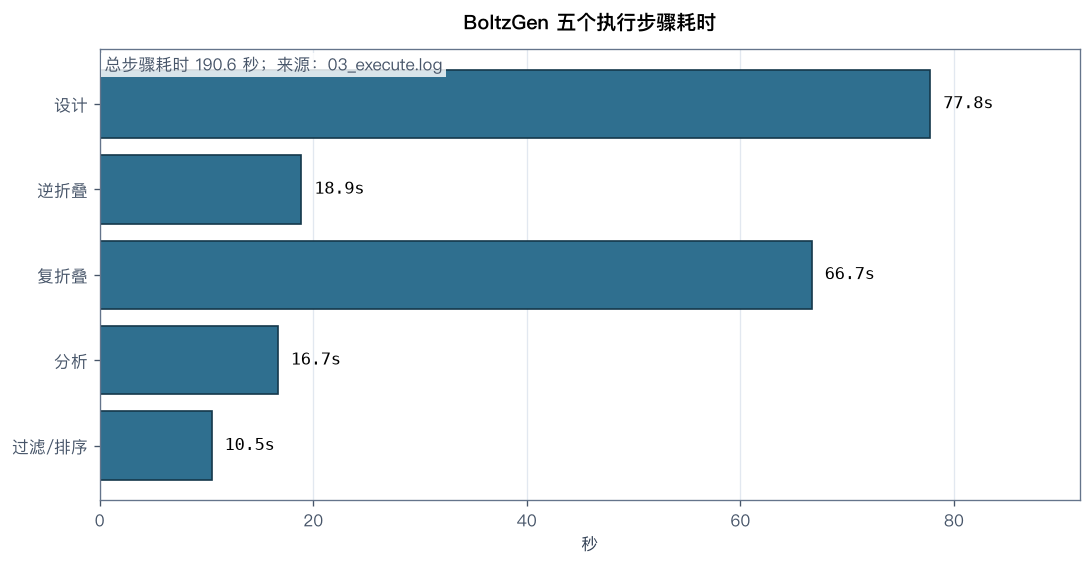

In [6]:
# 图 1：阶段耗时。横向条形便于阅读较长的中文/英文步骤名，坐标从 0 开始。
stage_label_map = {
    "design": "设计",
    "inverse_folding": "逆折叠",
    "folding": "复折叠",
    "analysis": "分析",
    "filtering": "过滤/排序",
}
plot_df = stage_durations.copy()
plot_df["label"] = plot_df["stage"].map(stage_label_map)

fig, ax = plt.subplots(figsize=(9.2, 4.8))
bars = ax.barh(plot_df["label"], plot_df["elapsed_seconds"], color="#2f6f8f", edgecolor="#15384b")
ax.invert_yaxis()
ax.set_xlim(0, max(plot_df["elapsed_seconds"]) * 1.18)
ax.set_xlabel("秒")
ax.set_title("BoltzGen 五个执行步骤耗时", pad=12)
# 将来源说明放在绘图区内部的空白上沿，避免与居中的标题相互覆盖。
ax.text(
    0.005,
    0.985,
    f"总步骤耗时 {plot_df['elapsed_seconds'].sum():.1f} 秒；来源：03_execute.log",
    transform=ax.transAxes,
    va="top",
    color="#475569",
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 2},
)
ax.grid(axis="x", color="#e2e8f0", linewidth=0.8)
ax.set_axisbelow(True)
for bar, value in zip(bars, plot_df["elapsed_seconds"], strict=True):
    ax.text(value + 1.2, bar.get_y() + bar.get_height() / 2, f"{value:.1f}s", va="center", fontfamily="monospace")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "stage_durations.png", bbox_inches="tight")
plt.show()

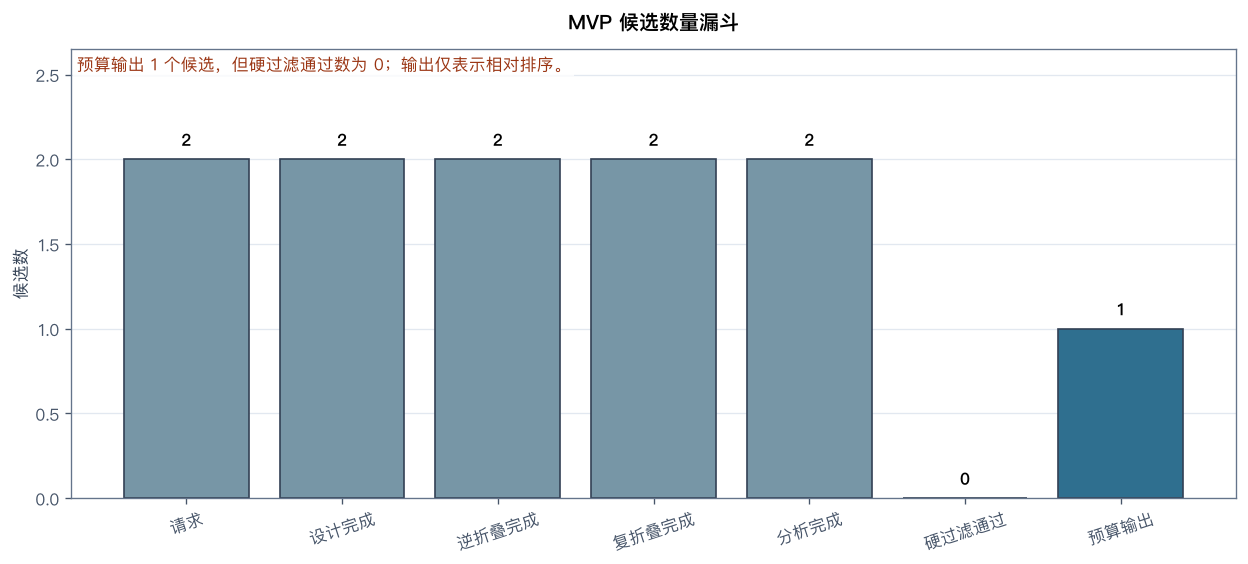

In [7]:
# 图 2：候选漏斗。最后两级用不同色调，强调“被输出”与“通过过滤”不是同义词。
colors = ["#7796a6"] * 5 + ["#d97706", "#2f6f8f"]
fig, ax = plt.subplots(figsize=(10.5, 4.8))
bars = ax.bar(funnel["阶段"], funnel["候选数"], color=colors, edgecolor="#334155")
ax.set_ylim(0, max(funnel["候选数"]) + 0.65)
ax.set_ylabel("候选数")
ax.set_title("MVP 候选数量漏斗", pad=12)
# 说明置于绘图区顶部，和标题分层呈现；当前 y 轴上沿有足够留白，不遮挡柱体。
ax.text(
    0.005,
    0.985,
    "预算输出 1 个候选，但硬过滤通过数为 0；输出仅表示相对排序。",
    transform=ax.transAxes,
    va="top",
    color="#9a3412",
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 2},
)
ax.grid(axis="y", color="#e2e8f0", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=18)
for bar, value in zip(bars, funnel["候选数"], strict=True):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.08, str(value), ha="center", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "candidate_funnel.png", bbox_inches="tight")
plt.show()

## 候选结果

只有两个候选，不足以画有统计意义的散点图或分布图。因此这里采用精确表格和逐指标小面板，避免从两个点推断“相关性”或“趋势”。

In [8]:
# 选择能回答“结构是否自洽、界面是否可信、是否接触指定热点、是否易开发”的核心列。
candidate_columns = [
    "id",
    "final_rank",
    "designed_sequence",
    "num_design",
    "design_to_target_iptm",
    "min_design_to_target_pae",
    "design_ptm",
    "filter_rmsd",
    "filter_rmsd_design",
    "bindsite_under_8rmsd",
    "delta_sasa_refolded",
    "plip_hbonds_refolded",
    "plip_saltbridge_refolded",
    "liability_score",
    "liability_num_violations",
    "pass_filters",
]
missing_candidate_columns = [column for column in candidate_columns if column not in candidate_metrics.columns]
assert not missing_candidate_columns, f"候选表缺少必要列：{missing_candidate_columns}"

candidate_view = candidate_metrics[candidate_columns].sort_values("final_rank").copy()
display(
    candidate_view.style.format(
        {
            "design_to_target_iptm": "{:.3f}",
            "min_design_to_target_pae": "{:.2f}",
            "design_ptm": "{:.3f}",
            "filter_rmsd": "{:.2f}",
            "filter_rmsd_design": "{:.2f}",
            "bindsite_under_8rmsd": "{:.0f}",
            "delta_sasa_refolded": "{:.1f}",
        }
    )
)

,id,final_rank,designed_sequence,num_design,design_to_target_iptm,min_design_to_target_pae,design_ptm,filter_rmsd,filter_rmsd_design,bindsite_under_8rmsd,delta_sasa_refolded,plip_hbonds_refolded,plip_saltbridge_refolded,liability_score,liability_num_violations,pass_filters
0,glp1_7_36_nanobody_mvp_0,1,GGTIKAMKDDGSTYYSTSSVGSSSFSVGSSYLDYWGQGTQVT,42,0.387,6.60,0.636,10.82,3.79,0,1069.3,3,0,151,23,False
1,glp1_7_36_nanobody_mvp_1,2,GETINFSSTTMNGPDGSTYYGEISSSASGASVSGVYWGQGTQVT,44,0.363,8.62,0.649,11.64,3.47,0,591.1,1,0,146,21,False


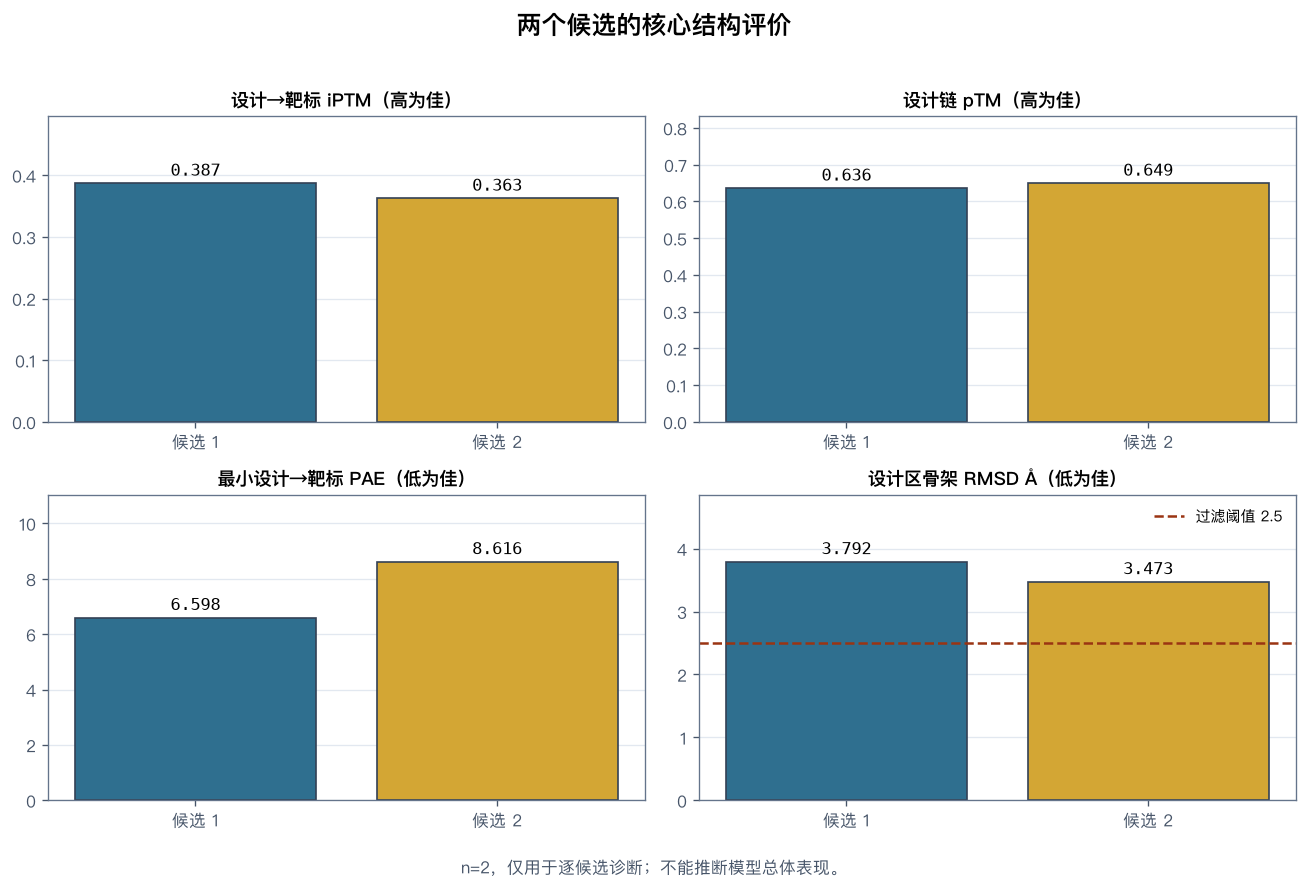

In [9]:
# 图 3：四个关键指标的小面板。每张图只比较同一单位下的两个候选。
score_specs = [
    ("design_to_target_iptm", "设计→靶标 iPTM（高为佳）", None),
    ("design_ptm", "设计链 pTM（高为佳）", None),
    ("min_design_to_target_pae", "最小设计→靶标 PAE（低为佳）", None),
    ("filter_rmsd_design", "设计区骨架 RMSD Å（低为佳）", 2.5),
]
ranked = candidate_metrics.sort_values("final_rank")
candidate_labels = [f"候选 {rank_value}" for rank_value in ranked["final_rank"]]
candidate_colors = ["#2f6f8f", "#d3a634"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7.4))
for ax, (column, title, threshold) in zip(axes.flat, score_specs, strict=True):
    values = ranked[column].astype(float).to_numpy()
    bars = ax.bar(candidate_labels, values, color=candidate_colors, edgecolor="#334155")
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, max(values.max() * 1.28, (threshold or 0) * 1.22, 0.1))
    ax.grid(axis="y", color="#e2e8f0", linewidth=0.8)
    ax.set_axisbelow(True)
    if threshold is not None:
        ax.axhline(threshold, color="#9a3412", linestyle="--", linewidth=1.5, label=f"过滤阈值 {threshold}")
        ax.legend(frameon=False, fontsize=9)
    for bar, value in zip(bars, values, strict=True):
        ax.text(bar.get_x() + bar.get_width() / 2, value + ax.get_ylim()[1] * 0.025, f"{value:.3f}", ha="center", fontfamily="monospace")

fig.suptitle("两个候选的核心结构评价", fontsize=15, fontweight="bold")
fig.text(0.5, 0.01, "n=2，仅用于逐候选诊断；不能推断模型总体表现。", ha="center", color="#475569")
fig.tight_layout(rect=[0, 0.04, 1, 0.96])
fig.savefig(FIGURE_DIR / "candidate_scorecards.png", bbox_inches="tight")
plt.show()

In [10]:
# 用保存的排名表生成严格、带数值的解释；不把相对 rank-1 写成“合格”。
best = ranked.iloc[0]
runner_up = ranked.iloc[1]
display(
    Markdown(
        f"""
### 如何读这两个候选

- **候选 1 被相对排序选中：** iPTM={best['design_to_target_iptm']:.3f}、最小设计→靶标 PAE={best['min_design_to_target_pae']:.2f}、ΔSASA={best['delta_sasa_refolded']:.1f} Å²、氢键={int(best['plip_hbonds_refolded'])}；这些界面指标整体优于候选 2。
- **但候选 1 的结构自洽性仍差：** 复折叠复合物骨架 RMSD={best['filter_rmsd']:.2f} Å，设计区骨架 RMSD={best['filter_rmsd_design']:.2f} Å，前者远高于 2.5 Å 门槛。
- **指定 N 端热点没有被命中：** 两个候选的 `bindsite_under_8rmsd` 都是 0。
- **开发性警告较多：** 候选 1 的 liability score={int(best['liability_score'])}、违规数={int(best['liability_num_violations'])}；候选 2 分别为 {int(runner_up['liability_score'])}、{int(runner_up['liability_num_violations'])}。这些是序列规则预警，不等于实验测得的稳定性或免疫原性。
"""
    )
)


### 如何读这两个候选

- **候选 1 被相对排序选中：** iPTM=0.387、最小设计→靶标 PAE=6.60、ΔSASA=1069.3 Å²、氢键=3；这些界面指标整体优于候选 2。
- **但候选 1 的结构自洽性仍差：** 复折叠复合物骨架 RMSD=10.82 Å，设计区骨架 RMSD=3.79 Å，前者远高于 2.5 Å 门槛。
- **指定 N 端热点没有被命中：** 两个候选的 `bindsite_under_8rmsd` 都是 0。
- **开发性警告较多：** 候选 1 的 liability score=151、违规数=23；候选 2 分别为 146、21。这些是序列规则预警，不等于实验测得的稳定性或免疫原性。


## 过滤失败

BoltzGen 的 `final_1_designs` 是预算输出目录。过滤器在没有候选通过全部硬门槛时仍会对所有候选相对排序，再按预算写出结果。因此必须检查逐项布尔列，而不能只看是否生成了 `rank1_*.cif`。

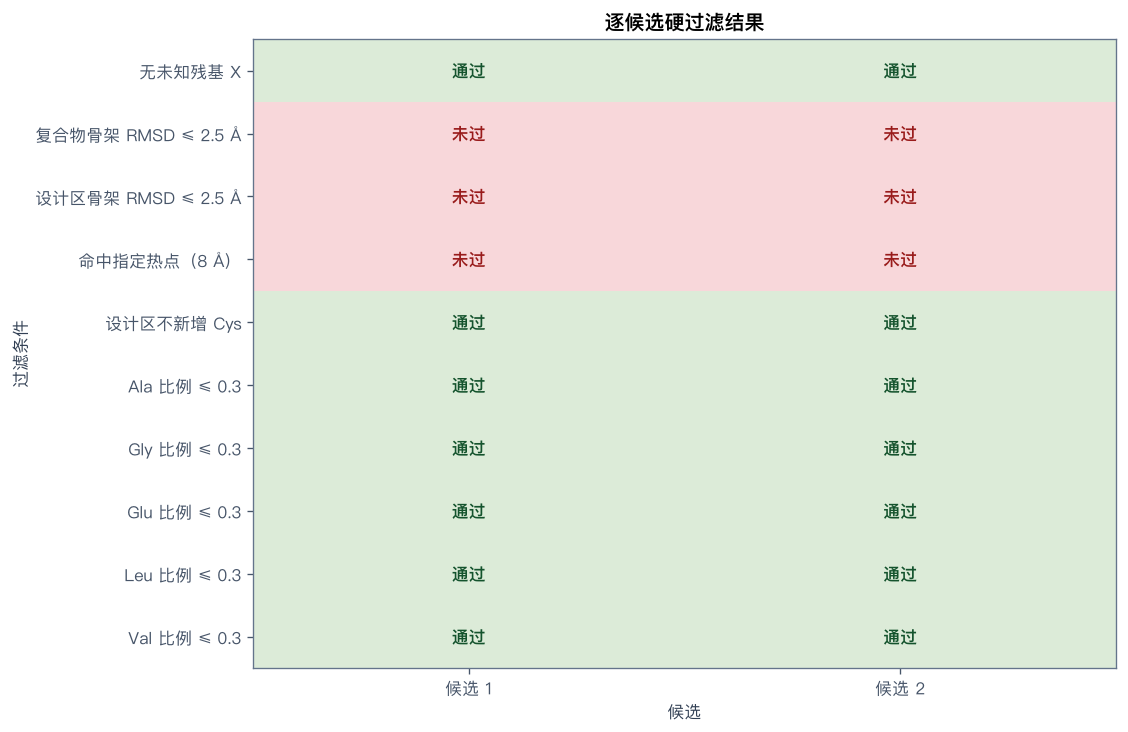

,候选,逐项通过数,过滤条件总数,全部通过
0,候选 1,7,10,False
1,候选 2,7,10,False


In [11]:
# 明确列出本轮实际使用的 10 个硬过滤条件，并重算每个候选逐项通过数。
filter_specs = [
    ("pass_has_x_filter", "无未知残基 X"),
    ("pass_filter_rmsd_filter", "复合物骨架 RMSD ≤ 2.5 Å"),
    ("pass_filter_rmsd_design_filter", "设计区骨架 RMSD ≤ 2.5 Å"),
    ("pass_bindsite_under_8rmsd_filter", "命中指定热点（8 Å）"),
    ("pass_CYS_fraction_filter", "设计区不新增 Cys"),
    ("pass_ALA_fraction_filter", "Ala 比例 ≤ 0.3"),
    ("pass_GLY_fraction_filter", "Gly 比例 ≤ 0.3"),
    ("pass_GLU_fraction_filter", "Glu 比例 ≤ 0.3"),
    ("pass_LEU_fraction_filter", "Leu 比例 ≤ 0.3"),
    ("pass_VAL_fraction_filter", "Val 比例 ≤ 0.3"),
]
missing_filter_columns = [column for column, _ in filter_specs if column not in candidate_metrics.columns]
assert not missing_filter_columns, f"候选表缺少过滤列：{missing_filter_columns}"

filter_matrix = ranked[[column for column, _ in filter_specs]].fillna(False).astype(bool).to_numpy()
filter_labels = [label for _, label in filter_specs]
recomputed_pass_count = filter_matrix.sum(axis=1)

# 图 4：布尔热图同时使用颜色和中文文本，避免只靠颜色传达状态，也避免
# 某些 macOS 字体缺少符号字形而显示成方框。
fig, ax = plt.subplots(figsize=(9.5, 6.2))
ax.imshow(filter_matrix.T.astype(int), cmap=ListedColormap(["#f8d7da", "#dcebd8"]), vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(candidate_labels)), candidate_labels)
ax.set_yticks(range(len(filter_labels)), filter_labels)
ax.set_title("逐候选硬过滤结果")
for row_index in range(filter_matrix.shape[1]):
    for column_index in range(filter_matrix.shape[0]):
        passed = filter_matrix[column_index, row_index]
        ax.text(
            column_index,
            row_index,
            "通过" if passed else "未过",
            ha="center",
            va="center",
            color="#14532d" if passed else "#991b1b",
            fontweight="bold",
            fontsize=10,
        )
ax.set_xlabel("候选")
ax.set_ylabel("过滤条件")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "filter_matrix.png", bbox_inches="tight")
plt.show()

filter_summary = pd.DataFrame(
    {
        "候选": candidate_labels,
        "逐项通过数": recomputed_pass_count,
        "过滤条件总数": filter_matrix.shape[1],
        "全部通过": ranked["pass_filters"].astype(bool).to_numpy(),
    }
)
display(filter_summary)

In [12]:
# 汇总共同失败项，避免把组成比例等已通过项目误判为主要问题。
failed_for_all = [
    label
    for matrix_column, label in zip(filter_matrix.T, filter_labels, strict=True)
    if not matrix_column.any()
]
display(
    Markdown(
        "### 共同失败的关键门槛\n"
        + "\n".join(f"- {item}" for item in failed_for_all)
        + "\n\n**解释：** 两个候选都通过了未知残基、Cys 与五种氨基酸组成过滤；失败集中在复折叠自洽性和指定热点接触。"
    )
)

### 共同失败的关键门槛
- 复合物骨架 RMSD ≤ 2.5 Å
- 设计区骨架 RMSD ≤ 2.5 Å
- 命中指定热点（8 Å）

**解释：** 两个候选都通过了未知残基、Cys 与五种氨基酸组成过滤；失败集中在复折叠自洽性和指定热点接触。

## NPZ 数据格式与轴解释

`.npz` 是一个压缩容器，内部以“键 → NumPy 数组”的方式保存多个数组。它不是单一矩阵，也不是训练数据集。不同目录中的 NPZ 承担不同角色：

1. **候选 token 元数据**：描述哪些残基可设计、哪些位置是热点；
2. **复折叠输出**：保存 token、原子坐标、原子到 token 的映射以及标量置信度；
3. **分析临时数据**：保存设计区序列编号和 Cα 坐标；
4. **逐候选指标**：大量 0 维标量，用于聚合为 CSV。

In [13]:
def npz_inventory(path: Path) -> list[dict[str, object]]:
    """只读取数组头与小型统计，不允许 pickle 对象。"""

    rows = []
    with np.load(path, allow_pickle=False) as archive:
        for key in archive.files:
            array = archive[key]
            rows.append(
                {
                    "键": key,
                    "shape": str(array.shape),
                    "dtype": str(array.dtype),
                    "元素数": int(array.size),
                }
            )
    return rows


# 选取 rank-1 候选的四类代表文件；其余候选遵循同一 schema，长度轴可能不同。
selected_id = str(best["id"])
npz_examples = {
    "设计 token 元数据": PIPELINE_DIR / "intermediate_designs" / f"{selected_id}.npz",
    "复折叠输出": PIPELINE_DIR / "intermediate_designs_inverse_folded/fold_out_npz" / f"{selected_id}.npz",
    "分析 Cα 数据": PIPELINE_DIR / "intermediate_designs_inverse_folded/metrics_tmp" / f"data_{selected_id}.npz",
    "逐候选指标": PIPELINE_DIR / "intermediate_designs_inverse_folded/metrics_tmp" / f"metrics_{selected_id}.npz",
}

npz_file_rows = []
for family, path in npz_examples.items():
    with np.load(path, allow_pickle=False) as archive:
        npz_file_rows.append(
            {
                "类别": family,
                "相对路径": str(path.relative_to(RUN_ROOT)),
                "文件大小(B)": path.stat().st_size,
                "数组键数": len(archive.files),
            }
        )
display(pd.DataFrame(npz_file_rows).style.format({"文件大小(B)": "{:,}"}))

# 复折叠 NPZ 的数组较多，先显示完整 schema，再在下一单元解释关键轴。
fold_npz_path = npz_examples["复折叠输出"]
display(pd.DataFrame(npz_inventory(fold_npz_path)))

,类别,相对路径,文件大小(B),数组键数
0,设计 token 元数据,outputs/02_mps_run/pipeline/intermediate_designs/glp1_7_36_nanobody_mvp_0.npz,"1,066",5
1,复折叠输出,outputs/02_mps_run/pipeline/intermediate_designs_inverse_folded/fold_out_npz/glp1_7_36_nanobody_mvp_0.npz,"32,808",28
2,分析 Cα 数据,outputs/02_mps_run/pipeline/intermediate_designs_inverse_folded/metrics_tmp/data_glp1_7_36_nanobody_mvp_0.npz,"2,170",5
3,逐候选指标,outputs/02_mps_run/pipeline/intermediate_designs_inverse_folded/metrics_tmp/metrics_glp1_7_36_nanobody_mvp_0.npz,"52,545",238


,键,shape,dtype,元素数
0,token_index,"(1, 155)",int64,155
1,mol_type,"(1, 155)",int64,155
2,res_type,"(1, 155, 33)",int64,5115
3,atom_resolved_mask,"(1, 1184)",bool,1184
4,coords,"(1, 1184, 3)",float32,3552
5,atom_to_token,"(1, 1184, 155)",bool,183520
6,backbone_mask,"(1, 1184)",float32,1184
7,min_interaction_pae,"(1,)",float32,1
8,min_design_to_target_pae,"(1,)",float32,1
9,interaction_pae,"(1,)",float32,1


### 关键数组逐轴解释

| 数组 | 本轮示例形状 | 每个轴代表什么 |
|---|---:|---|
| `design_mask` | `(N,)` | 第 0 轴是 token/残基；1 表示模型允许设计，0 表示目标或固定框架。纯蛋白输入中一个 token 对应一个氨基酸。|
| `binding_type` | `(N,)` | 第 0 轴同样是残基；值 1 表示正向结合位点。这里最前两个 token 是 GLP-1 的 His7、Ala8。|
| `mol_type` | `(N,)` 或 `(S,N)` | 分子类型枚举；0=`PROTEIN`。本轮没有 DNA、RNA 或小分子，所以全为 0。|
| `ss_type` | `(N,)` | 二级结构条件枚举：0 未指定、1 loop、2 helix、3 sheet。本轮未显式限制，所以全为 0。|
| `token_resolved_mask` | `(N,)` | 每个 token 是否有已解析结构；1 为存在。|
| `token_index` | `(S,N)` | 第 0 轴 `S` 是折叠样本数（本轮为 1）；第 1 轴是 token 顺序。|
| `res_type` | `(S,N,33)` | 样本 × token × 33 类残基/特殊 token 的 one-hot 向量；最后一轴不是空间坐标。|
| `coords` | `(S,A,3)` | 样本 × 原子槽 × `(x,y,z)`，坐标单位 Å。`A` 含 padding 原子槽，须与 `atom_resolved_mask` 联用。|
| `atom_resolved_mask` | `(S,A)` | 每个原子槽是否实际存在；False 的 padding 不应参与几何计算。|
| `atom_to_token` | `(S,A,N)` | 布尔映射矩阵；行是原子槽，列是 token。真实原子行通常只有一个 True，表示它属于哪个残基。|
| `backbone_mask` | `(S,A)` | 原子槽是否属于骨架原子。|
| `input_coords` | `(S,1,A,3)` | 保存给折叠器的输入坐标；本轮前两个轴均为单样本维，随后是原子槽和 XYZ。|
| 置信度键 | `(S,)` | 每个折叠样本一个标量，例如 `design_to_target_iptm`、`design_ptm`、`min_design_to_target_pae`。|
| `design_seq` | `(D,)` | 分析文件中 D 个设计残基的整数 token ID。|
| `ca_coords` | `(D,3)` | 生成结构中 D 个设计残基的 Cα 坐标。|
| `ca_coords_refolded` | `(D,3)` | 复折叠结构中同一批设计残基的 Cα 坐标。|

其中 `N` 随插入长度变化：候选 1 为 155，候选 2 为 157；`D` 分别为 42、44。`S=1` 是因为本轮每候选只请求一个折叠样本。

In [14]:
# 对 rank-1 的映射矩阵做可复核检查，并展示少量真实值而不是倾倒整个数组。
with np.load(npz_examples["设计 token 元数据"], allow_pickle=False) as token_npz:
    token_design_mask = token_npz["design_mask"]
    token_binding_type = token_npz["binding_type"]

with np.load(fold_npz_path, allow_pickle=False) as fold_npz:
    atom_to_token = fold_npz["atom_to_token"][0]
    atom_resolved = fold_npz["atom_resolved_mask"][0]
    fold_coords = fold_npz["coords"][0]
    residue_one_hot = fold_npz["res_type"][0]

resolved_mapping = atom_to_token[atom_resolved]
row_true_counts = resolved_mapping.sum(axis=1)

mapping_checks = pd.DataFrame(
    [
        ("token 数 N", len(token_design_mask)),
        ("设计 token 数", int(token_design_mask.sum())),
        ("binding token 数", int((token_binding_type == 1).sum())),
        ("原子槽数 A", atom_to_token.shape[0]),
        ("已解析原子槽", int(atom_resolved.sum())),
        ("每个已解析原子恰映射到一个 token", bool(np.all(row_true_counts == 1))),
        ("每个 token 的 residue one-hot 和为 1", bool(np.all(residue_one_hot.sum(axis=1) == 1))),
        ("坐标末轴长度", fold_coords.shape[-1]),
    ],
    columns=["检查", "结果"],
)
display(mapping_checks)

# 展示映射矩阵的左上角切片：行=前 12 个原子槽，列=前 12 个 token。
mapping_slice = pd.DataFrame(
    atom_to_token[:12, :12].astype(int),
    index=[f"atom_{index}" for index in range(12)],
    columns=[f"token_{index}" for index in range(12)],
)
display(mapping_slice)

,检查,结果
0,token 数 N,155
1,设计 token 数,42
2,binding token 数,2
3,原子槽数 A,1184
4,已解析原子槽,1162
5,每个已解析原子恰映射到一个 token,True
6,每个 token 的 residue one-hot 和为 1,True
7,坐标末轴长度,3


,token_0,token_1,token_2,token_3,token_4,token_5,token_6,token_7,token_8,token_9,token_10,token_11
atom_0,1,0,0,0,0,0,0,0,0,0,0,0
atom_1,1,0,0,0,0,0,0,0,0,0,0,0
atom_2,1,0,0,0,0,0,0,0,0,0,0,0
atom_3,1,0,0,0,0,0,0,0,0,0,0,0
atom_4,1,0,0,0,0,0,0,0,0,0,0,0
atom_5,1,0,0,0,0,0,0,0,0,0,0,0
atom_6,1,0,0,0,0,0,0,0,0,0,0,0
atom_7,1,0,0,0,0,0,0,0,0,0,0,0
atom_8,1,0,0,0,0,0,0,0,0,0,0,0
atom_9,1,0,0,0,0,0,0,0,0,0,0,0


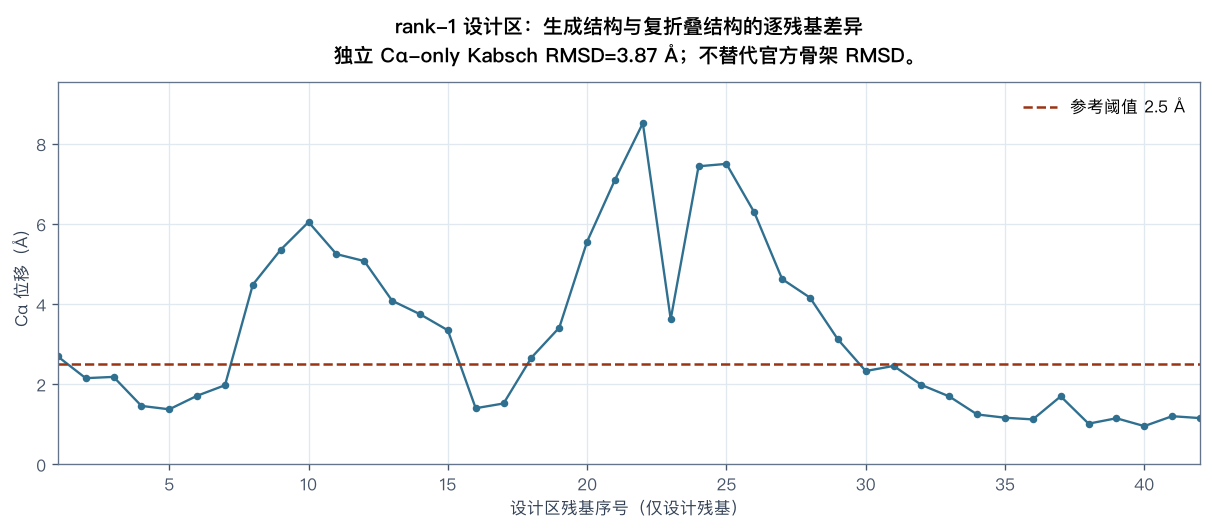

Cα-only 对齐后 RMSD：3.870 Å


In [15]:
# 独立做一次 Cα-only Kabsch 对齐，直观看设计区在复折叠后的逐残基位移。
# 该计算只用于 sanity check；官方 filter_rmsd_design 使用骨架原子和自身实现，数值不必完全相同。
with np.load(npz_examples["分析 Cα 数据"], allow_pickle=False) as analysis_npz:
    ca_generated = analysis_npz["ca_coords"].astype(float)
    ca_refolded = analysis_npz["ca_coords_refolded"].astype(float)


def kabsch_align(moving: np.ndarray, reference: np.ndarray) -> np.ndarray:
    """将 moving 通过刚体旋转/平移最小二乘对齐到 reference。"""

    moving_centered = moving - moving.mean(axis=0, keepdims=True)
    reference_centered = reference - reference.mean(axis=0, keepdims=True)
    covariance = moving_centered.T @ reference_centered
    left, _, right_t = np.linalg.svd(covariance)
    correction = np.eye(3)
    correction[-1, -1] = np.sign(np.linalg.det(left @ right_t))
    rotation = left @ correction @ right_t
    return moving_centered @ rotation + reference.mean(axis=0, keepdims=True)


ca_generated_aligned = kabsch_align(ca_generated, ca_refolded)
ca_displacement = np.linalg.norm(ca_generated_aligned - ca_refolded, axis=1)
ca_rmsd = float(np.sqrt(np.mean(np.square(ca_displacement))))

fig, ax = plt.subplots(figsize=(10.2, 4.5))
ax.plot(np.arange(1, len(ca_displacement) + 1), ca_displacement, color="#2f6f8f", marker="o", markersize=3.5, linewidth=1.4)
ax.axhline(2.5, color="#9a3412", linestyle="--", linewidth=1.5, label="参考阈值 2.5 Å")
ax.set_xlim(1, len(ca_displacement))
ax.set_ylim(0, max(ca_displacement.max() * 1.12, 3.0))
ax.set_xlabel("设计区残基序号（仅设计残基）")
ax.set_ylabel("Cα 位移（Å）")
# 把说明作为标题的第二行，确保任何窗口宽度下都不会与主标题重叠。
ax.set_title(
    "rank-1 设计区：生成结构与复折叠结构的逐残基差异\n"
    f"独立 Cα-only Kabsch RMSD={ca_rmsd:.2f} Å；不替代官方骨架 RMSD。",
    pad=12,
)
ax.grid(color="#e2e8f0", linewidth=0.8)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "rank1_ca_displacement.png", bbox_inches="tight")
plt.show()

print(f"Cα-only 对齐后 RMSD：{ca_rmsd:.3f} Å")

## 结论边界

### 本次可以确认

- 实验性 MPS 环境完成了 `check → design → inverse_folding → folding → analysis → filtering` 全链路，所有阶段返回码为 0。
- 两个请求候选均有骨架、序列、复折叠结构和完整指标；没有中途丢样。
- 结果文件格式、token/原子映射以及关键数组形状自洽。
- 排名器在两个失败候选中选出了一个相对最优项，数据来源和排名过程可追踪。

### 本次不能确认

- **不能宣称获得合格 binder：** 两个候选均未通过全部硬过滤。
- **不能宣称结合 GLP-1：** 计算置信度和接触指标不是实验亲和力；指定 His7/Ala8 热点也没有命中。
- **不能宣称 7–36/9–36 选择性：** 本轮只输入正靶，没有对 9–36 进行同候选反靶复评分。
- **不能宣称识别 C 端酰胺：** 标准聚合物 CIF 没有原子级证明模型看到了 C 端 NH₂。
- **不能把 7XL0 当作生产级 scaffold：** 它只是官方示例，尚未完成项目级框架筛选与可开发性确认。
- **不能评价真实命中率：** `n=2`、降低采样步数、每候选仅一次复折叠，且 CLI 没有统一随机种子。

**总体可信度：** `Share with caveats`——工程闭环结论可信；生物学效力与选择性结论尚无证据。

## 下一轮

1. **先修正“热点未命中”问题。** 检查 binding 位点在输入检查 CIF 中是否对应 His7/Ala8；保留硬过滤，不通过时不要用“放宽阈值”包装成命中。
2. **增加候选而非只比较两个样本。** 先做 10–20 个工程调试候选；稳定后至少 50 个用于初步校准。正式筛选仍需要远大于 MVP 的采样规模。
3. **恢复更充分的推理设置。** 将设计/折叠 sampling steps 和 recycling 向官方默认值恢复，并为每个候选增加复折叠重复，以区分偶然失败与稳定失败。
4. **比较 checkpoint 策略。** 分批测试 `diverse` 与 `adherence`，不要在极小样本中混合后再归因。
5. **建立真正的选择性复评分。** 对同一候选分别输入 GLP-1(7–36) 与 GLP-1(9–36) 的多构象集合，比较 iPTM/PAE、界面接触和 ΔSASA 的正负靶差值；9IVG 的缺失残基限制必须保留。
6. **加入独立结构复核。** 使用另一折叠模型或独立配置复预测，并检查界面氢键、盐桥、埋藏面积、聚集/氧化/脱酰胺等 liability。
7. **进入实验前再做序列与 scaffold 筛选。** 核对 VHH 保守框架、二硫键、表达风险、聚集风险和免疫原性；最终以 SPR/BLI 正靶、反靶和混合样本 LC–MS 捕获实验为准。

---

### 可复现文件

- 运行状态：`outputs/02_mps_run/mvp_run_status.json`
- 输入指纹：`outputs/02_mps_run/input_manifest.json`
- 执行日志：`logs/03_execute.log`
- 全候选指标：`outputs/02_mps_run/pipeline/final_ranked_designs/all_designs_metrics.csv`
- 最终预算指标：`outputs/02_mps_run/pipeline/final_ranked_designs/final_designs_metrics_1.csv`
- 复折叠 NPZ：`outputs/02_mps_run/pipeline/intermediate_designs_inverse_folded/fold_out_npz/`
- 逐候选分析 NPZ：`outputs/02_mps_run/pipeline/intermediate_designs_inverse_folded/metrics_tmp/`